In [1]:
%matplotlib inline

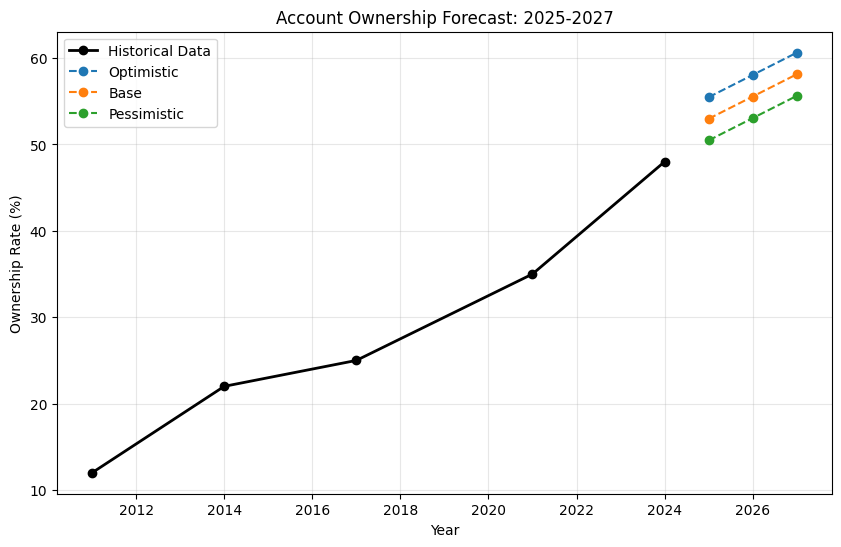

      Optimistic       Base  Pessimistic
2025   55.470696  52.970696    50.470696
2026   58.045788  55.545788    53.045788
2027   60.620879  58.120879    55.620879


In [5]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# 1. Historical Data
years_hist = np.array([2011, 2014, 2017, 2021, 2024])
ownership_hist = np.array([12.0, 22.0, 25.0, 35.0, 48.0])

# 2. Forecasting Engine
def run_forecast(years_proj, event_boost):
    z = np.polyfit(years_hist, ownership_hist, 1)
    p = np.poly1d(z)
    baseline = p(years_proj)
    
    scenarios = {
        "Optimistic": baseline + (event_boost * 1.5),
        "Base": baseline + event_boost,
        "Pessimistic": baseline + (event_boost * 0.5)
    }
    return pd.DataFrame(scenarios, index=years_proj)

# 3. Execution (This creates 'forecast_df')
years_proj = [2025, 2026, 2027]
forecast_df = run_forecast(years_proj, event_boost=5.0)

# 4. Visualization (This now has access to 'forecast_df')
plt.figure(figsize=(10, 6))
plt.plot(years_hist, ownership_hist, 'ko-', label="Historical Data", linewidth=2)

for label in forecast_df.columns:
    plt.plot(forecast_df.index, forecast_df[label], '--o', label=label)

plt.title("Account Ownership Forecast: 2025-2027")
plt.xlabel("Year")
plt.ylabel("Ownership Rate (%)")
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

# 5. Display Table
print(forecast_df)